## Podracing model

In [26]:
using JuMP, Gurobi

k = 4              # number of waypoints
T = zeros(Int,k)   # vector of timepoints
xw = zeros(2,k)    # vector of waypoint locations

T[1] = 1
T[2] = 20
T[3] = 50
T[4] = 60

# define waypoints
way_xy = [ 1   4   6   1
           1   3   0   1 ]

function solveOpt(λ)
    
    m = Model(solver = GurobiSolver(OutputFlag=0))
    
    @variable(m, x[1:2,1:T[k]])  # position at each time
    @variable(m, v[1:2,1:T[k]])  # velocity at each time
    @variable(m, u[1:2,1:T[k]])  # thruster input at each time

    # satisfy the dynamics (with zero initial velocity)
    @constraint(m, v[:,1] .== [0;0])
    
    # model system dynamics
    for t in 1:T[k]-1
        @constraint(m, x[:,t+1] .== x[:,t] + v[:,t])
        @constraint(m, v[:,t+1] .== v[:,t] + u[:,t])
    end

    # hit all the waypoints
#     for i in 1:k
#         @constraint(m, x[:,T[i]] .== way_xy[:,i])
#     end
    
    # hit the first waypoint only
     for i in 1
         @constraint(m, x[:,T[i]] .== xw[:,i])
     end
    
    # minimize 2-norm (THIS IS LEAST-SQUARES)
    @objective(m, Min, sum(u.^2) + λ*sum( (x[:,T]-way_xy).^2 ) )
    solve(m)
    
    y1 = getvalue(sum(u.^2))
    y2 = getvalue(sum( (x[:,T]-way_xy).^2  ))
    xopt = getvalue(x)
    
    return (y1,y2,xopt)
end
;

## Plot Model Output

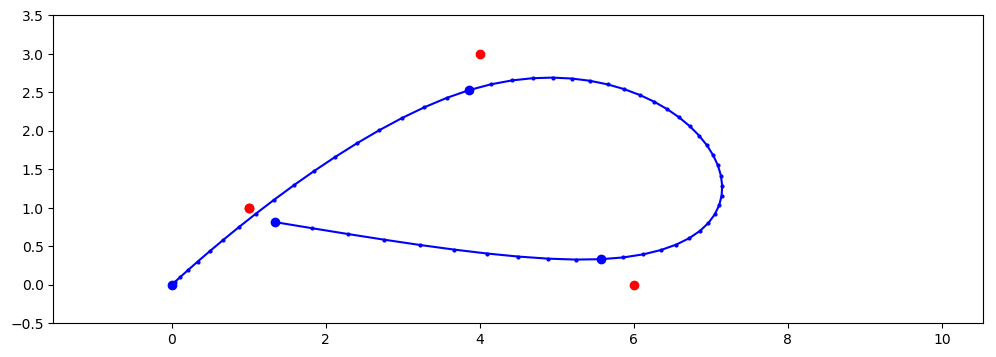

In [27]:
λ = 0.01
(y1x,y2x,x) = solveOpt(λ)

using PyPlot
figure(figsize=(12,4))
plot( x[1,:], x[2,:], "b.-", markersize=4 )
plot( x[1,:][T], x[2,:][T], "b.", markersize=12 )
plot( way_xy[1,:], way_xy[2,:], "r.", markersize=12 )
axis("equal")
axis((1.,8.,-.5,3.5));

## Compute tradeoff curve

In [7]:
Npts = 30
y1 = zeros(Npts)
y2 = zeros(Npts)
for (i,λ) in enumerate(logspace(-5,1,Npts))
    (y1[i],y2[i],uu) = solveOpt(λ)
end;

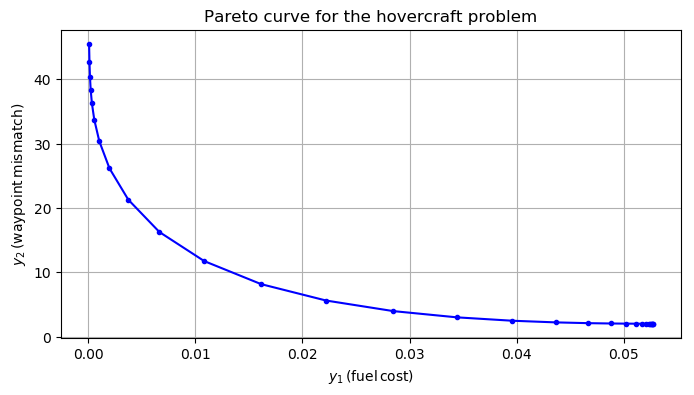

In [8]:
using PyPlot
figure(figsize=(8,4))
plot( y1, y2, "b.-" )
xlabel(L"y_1\, (\sf fuel\, cost)")
ylabel(L"y_2\, (\sf waypoint\, mismatch)");
title("Pareto curve for the hovercraft problem")
grid()